**nn**: bloques y capas de redes neuronales.

**optim**: optimizadores para entrenar el modelo (Adam, AdamW, SGD, etc.).

**from torch.utils.data import DataLoader, random_split**
    **DataLoader**: para iterar sobre el dataset en batches.
    **random_split**: dividir dataset en entrenamiento y validación.

**from tqdm import tqdm**: Barra de progreso para visualizar avances durante entrenamiento.

**import timm**: librería de modelos de visión preentrenados (ResNet, ViT, EfficientNet, etc.).

In [1]:
# ===============================
# Notebook 03 - Entrenamiento del modelo
# ===============================

import torch
import os
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import timm
from dataset_utils import GestosDataset, transformacion, mostrar_imagenes_por_clase

D:\entornos\tesis\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
D:\entornos\tesis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Instancia de clase GestosDataset:**

- Recorre todas las carpetas de clases.
- Guarda los paths de las imágenes y sus etiquetas.
- Aplica las transformaciones de aumento y normalización al cargar las imágenes.

In [2]:
carpeta_modelos = "modelos"
os.makedirs(carpeta_modelos, exist_ok=True)

dataset_completo = torch.load(os.path.join(carpeta_modelos, "dataset_gestos.pt"), weights_only = False)

print("Número total de imágenes:", len(dataset_completo))
print("Clases encontradas:", dataset_completo.clases)

Número total de imágenes: 12911
Clases encontradas: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '_']


In [3]:
clase = "5"
indices_clase = [i for i, c in enumerate(dataset_completo.etiquetas) if dataset_completo.clases[c] == clase]
print(f"Número de imágenes en clase {clase}: {len(indices_clase)}")

Número de imágenes en clase 5: 400


In [4]:
import os

carpeta = r"E:\Mis Documentos\Christian\Tesis\tesis_gestos\data\Clases_200_comp\2"
print(len(os.listdir(carpeta)))

200


# Dividir dataset en train y validación

In [5]:
train_size = int(0.8 * len(dataset_completo))

val_size = len(dataset_completo) - train_size

train_dataset, val_dataset = random_split(dataset_completo, [train_size, val_size])

batch_size = 8  # Cada iteración del DataLoader entregará 8 imágenes y etiquetas.

train_loader = DataLoader(train_dataset, 
                          batch_size = batch_size, 
                          shuffle = True,   # mezcla las imágenes en cada epoch y evita patrones de orden.
                          num_workers = 2)  # usa dos procesos para cargar imágenes en paralelo (más rápido).

val_loader = DataLoader(val_dataset, 
                        batch_size = batch_size, 
                        shuffle = False,   # no mezcla, la evaluación es consistente. 
                        num_workers = 2)

# Crear modelo ViT

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_clases = len(dataset_completo.clases)

modelo_vit = timm.create_model("vit_tiny_patch16_224",     # Versión Tiny del Vision Transformer, patches 16×16 y entrada 224×224 px.
                               pretrained = True,          # Carga pesos preentrenados en ImageNet.
                               num_classes = num_clases)

modelo_vit = modelo_vit.to(device) # fue definido como cuda

# Definir criterio y optimizador

In [7]:
loss_fn = nn.CrossEntropyLoss()                                   # Penaliza al modelo cuando predice la clase incorrecta.
optimizer = optim.AdamW(modelo_vit.parameters(), lr=1e-4)         # Optimiza todos los parámetros del modelo ViT (con decay de pesos mejor manejado)

--------------------------

# Entrenamiento del modelo con AMP y checkpoints

En esta celda se realiza el **entrenamiento del modelo ViT** usando PyTorch, con las siguientes características:

- **AMP (Automatic Mixed Precision):** Acelera el entrenamiento y reduce uso de memoria usando float16 donde es seguro.
- **Checkpoints por epoch:** Guardan el estado del modelo y optimizador para poder reanudar o evaluar el entrenamiento intermedio.

# Checkpoint por epoch

Guarda un diccionario con:

**epoch**: número de epoch actual.

**modelo_state_dict**: pesos del modelo.

**optimizer_state_dict**: estado del optimizador.

**loss**: pérdida promedio del entrenamiento.

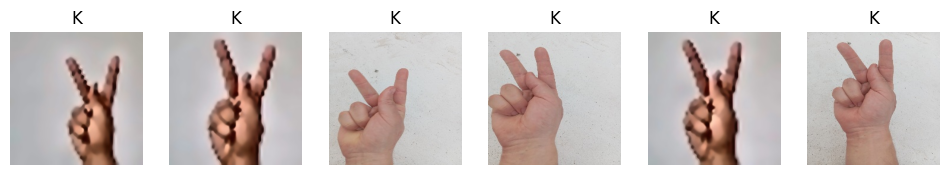

In [8]:
mostrar_imagenes_por_clase(dataset_completo, "K", num_imagenes = 6)

In [9]:
# Parámetros recomendados
max_epochs = 200
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
patience_es = 15                # early stopping patience
patience_reduce = 6            # ReduceLROnPlateau patience
factor_reduce = 0.5
min_lr = 1e-6

# Scheduler para bajar LR cuando la validación se estanque
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=factor_reduce,
    patience=patience_reduce,
    min_lr=min_lr
)

best_val_acc = 0.0
best_epoch = 0
es_counter = 0

# Para graficar después
history = {"train_loss": [], "val_loss": [], "val_acc": [], "lr": []}

scaler = torch.cuda.amp.GradScaler()  # si usás AMP

for epoch in range(max_epochs):
    modelo_vit.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Train {epoch+1}/{max_epochs}"):
        images = images.float().to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = modelo_vit(images)
            loss = loss_fn(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    history["train_loss"].append(epoch_train_loss)

    # ===========================
    # VALIDACIÓN
    # ===========================
    modelo_vit.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.float().to(device)
            labels = labels.to(device)
            with torch.cuda.amp.autocast():
                outputs = modelo_vit(images)
                loss = loss_fn(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = correct / total

    history["val_loss"].append(epoch_val_loss)
    history["val_acc"].append(epoch_val_acc)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    print(f"Epoch [{epoch+1}/{max_epochs}] "
          f"train_loss: {epoch_train_loss:.4f} "
          f"val_loss: {epoch_val_loss:.4f} "
          f"val_acc: {epoch_val_acc:.4f} "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # ===========================
    # Scheduler por val_loss
    # ===========================
    prev_lr = optimizer.param_groups[0]['lr']
    scheduler.step(epoch_val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr < prev_lr:
        print(f"ReduceLROnPlateau: LR reducido de {prev_lr:.6f} a {new_lr:.6f}")

    # ===========================
    # Guardar checkpoint por epoch
    # ===========================
    checkpoint = {
        "epoch": epoch + 1,
        "modelo_state_dict": modelo_vit.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": epoch_train_loss,
        "val_loss": epoch_val_loss,
        "val_acc": epoch_val_acc
    }
    torch.save(checkpoint, os.path.join(carpeta_modelos, f"checkpoint_epoch_{epoch+1}.pth"))

    # ===========================
    # Guardar mejor modelo
    # ===========================
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_epoch = epoch + 1
        torch.save(modelo_vit.state_dict(), os.path.join(carpeta_modelos, "best_model.pth"))
        print(f"*** Nuevo best_model guardado en epoch {best_epoch} "
              f"(val_acc={best_val_acc:.4f})")

        es_counter = 0  # reset early stopping
    else:
        es_counter += 1

    # ===========================
    # Early stopping
    # ===========================
    if es_counter >= patience_es:
        print(f"Early stopping en epoch {epoch+1} "
              f"(sin mejora en {patience_es} epochs). "
              f"Mejor epoch: {best_epoch} con val_acc={best_val_acc:.4f}")
        break


Train 1/200:   0%|                                                                            | 0/1291 [00:00<?, ?it/s]D:\entornos\tesis\Lib\site-packages\timm\layers\attention.py:80: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  x = F.scaled_dot_product_attention(
Train 1/200: 100%|█████████████████████████████████████████████████████████████████| 1291/1291 [02:47<00:00,  7.73it/s]


Epoch [1/200] train_loss: 0.2902 val_loss: 0.0181 val_acc: 0.9977 LR: 0.000100
*** Nuevo best_model guardado en epoch 1 (val_acc=0.9977)


Train 2/200: 100%|█████████████████████████████████████████████████████████████████| 1291/1291 [01:23<00:00, 15.50it/s]


Epoch [2/200] train_loss: 0.0428 val_loss: 0.0087 val_acc: 0.9973 LR: 0.000100


Train 3/200: 100%|█████████████████████████████████████████████████████████████████| 1291/1291 [01:23<00:00, 15.42it/s]


...

Epoch [23/200] train_loss: 0.0015 val_loss: 0.0044 val_acc: 0.9992 LR: 0.000050


Train 24/200: 100%|████████████████████████████████████████████████████████████████| 1291/1291 [01:22<00:00, 15.70it/s]


Epoch [24/200] train_loss: 0.0031 val_loss: 0.0084 val_acc: 0.9985 LR: 0.000050


Train 25/200: 100%|████████████████████████████████████████████████████████████████| 1291/1291 [01:22<00:00, 15.70it/s]


Epoch [25/200] train_loss: 0.0030 val_loss: 0.0036 val_acc: 0.9988 LR: 0.000050
Early stopping en epoch 25 (sin mejora en 15 epochs). Mejor epoch: 10 con val_acc=0.9996


-----------------------------------------------
Guardar modelo entrenado

In [10]:
torch.save(modelo_vit.state_dict(), os.path.join(carpeta_modelos, "modelo_vit_final.pth"))
print("Modelo guardado en modelo_vit_final.pth")

Modelo guardado en modelo_vit_final.pth


In [11]:
import json

# Guardar clases en un archivo
with open("clases.json", "w") as f:
    json.dump(dataset_completo.clases, f)

print("Clases guardadas en clases.json")

Clases guardadas en clases.json


In [12]:
# ===============================
# Cargar el mejor checkpoint
# ===============================
best_epoch = 6  # Cambiar si EarlyStopping reporta otro
checkpoint = torch.load(os.path.join(carpeta_modelos, f"checkpoint_epoch_{best_epoch}.pth"), 
                        map_location=device, 
                        weights_only=False)

modelo_vit.load_state_dict(checkpoint["modelo_state_dict"])
print(f"Modelo cargado desde checkpoint_epoch_{best_epoch}.pth")

Modelo cargado desde checkpoint_epoch_6.pth


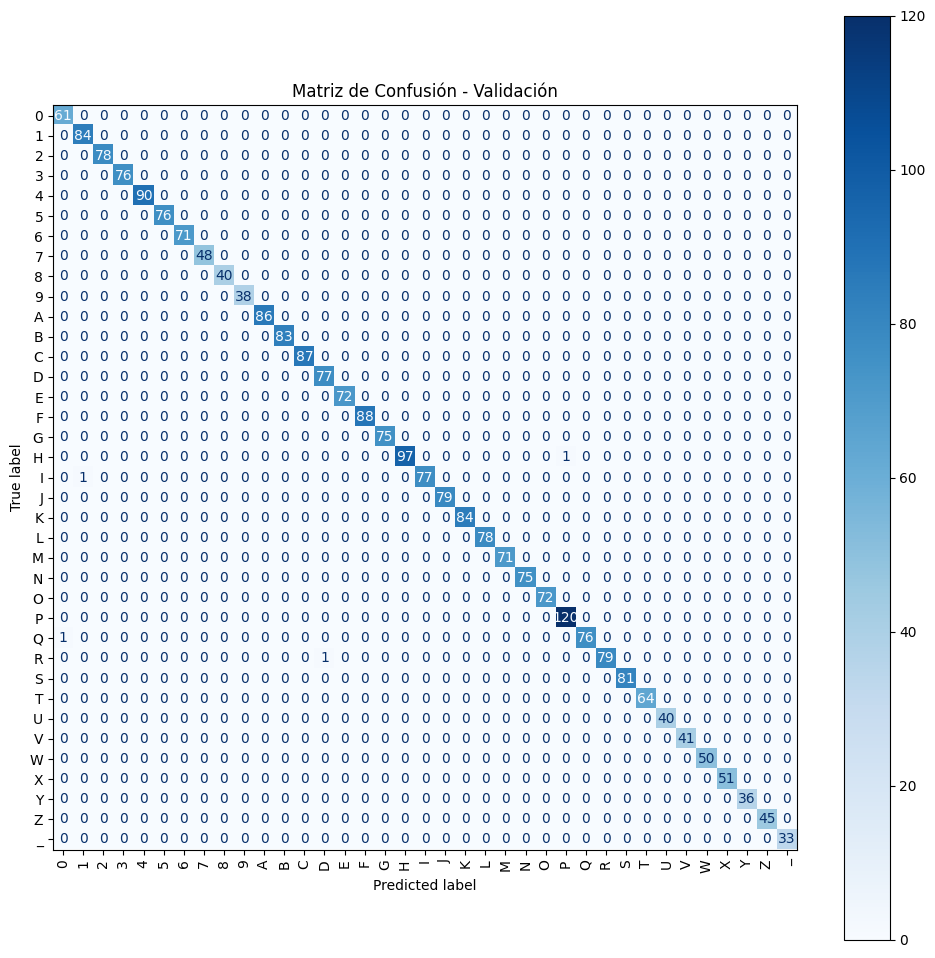

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Evaluar en validación
# ===============================
modelo_vit.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.float().to(device)
        labels = labels.to(device)

        outputs = modelo_vit(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

# ===============================
# Matriz de confusión
# ===============================
cm = confusion_matrix(all_labels, all_preds, labels=range(len(dataset_completo.clases)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset_completo.clases)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=90)
plt.title("Matriz de Confusión - Validación")
plt.show()
